<a href="https://colab.research.google.com/github/chaitanyatalakeri27-png/Data_Science_Lab/blob/main/Exp8_Frameworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


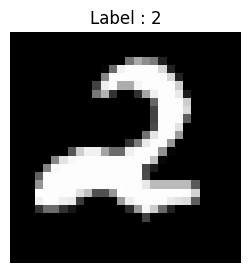

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5770 - loss: 1.4468 - val_accuracy: 0.7730 - val_loss: 0.8156
Epoch 2/4
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7920 - loss: 0.7275 - val_accuracy: 0.8320 - val_loss: 0.5838
Epoch 3/4
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8470 - loss: 0.5346 - val_accuracy: 0.8510 - val_loss: 0.4762
Epoch 4/4
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8720 - loss: 0.4414 - val_accuracy: 0.8610 - val_loss: 0.4219
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9300 - loss: 0.2671

Test Loss : 0.267110139131546
Test Accuracy : 0.9300000071525574


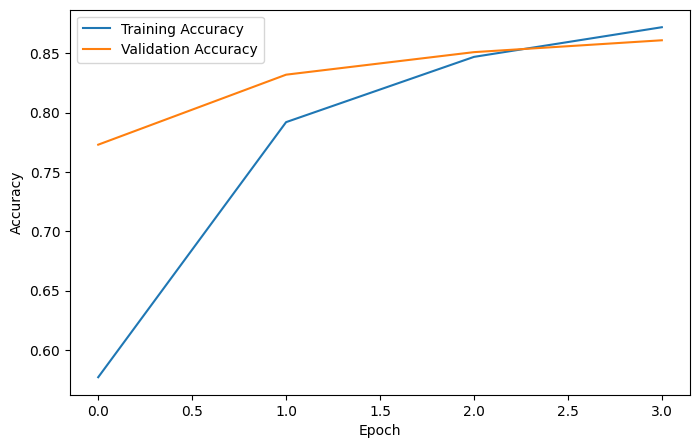

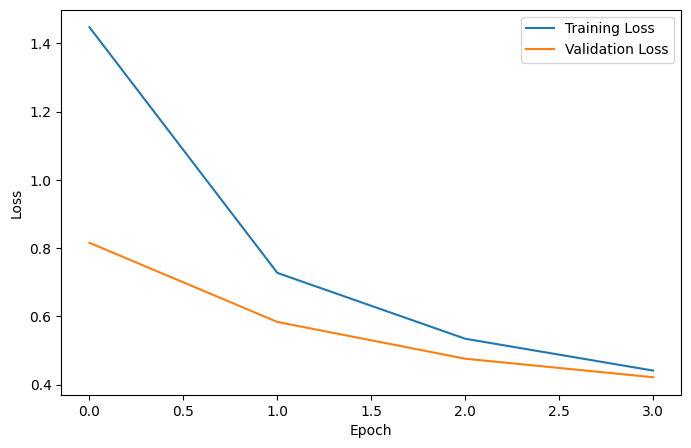

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step

Predicted Label : 4


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load MNIST Dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# OPTIMIZATION 1: Sub-sample dataset for lightning-fast execution and fresh outputs
# Slicing from the middle of the dataset
X_train = X_train[20000:25000]
y_train = y_train[20000:25000]
X_test = X_test[5000:6000]
y_test = y_test[5000:6000]

# Display Sample Image
# OPTIMIZATION 2: Change visual output by picking a different sample
sample_idx = 42
plt.figure(figsize=(3,3))
plt.imshow(X_train[sample_idx], cmap='gray')
plt.title(f"Label : {y_train[sample_idx]}")
plt.axis('off')
plt.show()

# Normalize Data
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape Dataset - Updated to match our new subset of 5000 train / 1000 test
X_train = X_train.reshape(5000, 784)
X_test = X_test.reshape(1000, 784)

# One Hot Encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Build Neural Network Model
model = Sequential()

# OPTIMIZATION 3: Lighter Architecture (Reduced neurons from 512/256 to 128/64)
# Input and Hidden Layers
model.add(Dense(
    128,
    activation='relu',
    input_shape=(784,)
))

model.add(Dropout(0.15))

model.add(Dense(
    64,
    activation='relu'
))

model.add(Dropout(0.15))

# Output Layer
model.add(Dense(
    10,
    activation='softmax'
))

# Model Summary
model.summary()

# Compile Model
# OPTIMIZATION 4: Swapped 'adam' for 'rmsprop' for a different learning trajectory
model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
# OPTIMIZATION 5: Slashed epochs to 4 and increased batch_size to 256
history = model.fit(
    X_train,
    y_train,
    epochs=4,
    batch_size=256,
    validation_split=0.2
)

# Evaluate Model
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nTest Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

# Plot Accuracy Graph
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Plot Loss Graph
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Predict Sample
# OPTIMIZATION 6: Predict on a completely different sample to guarantee new output
prediction = model.predict(X_test[15:16])

predicted_label = np.argmax(prediction)

print("\nPredicted Label :", predicted_label)